In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np


### Step 01: Load Dataset

In [32]:
df = pd.read_csv("./dataset/dataset.csv")

#### Dataset structure

Dataset is simply a two column csv file, where
`col1` = `text`, which contains the article, while
`col2` = `label`, which contains the label whether it is sports or politics

In [33]:
print(df.head(5))

num_sports_record = (df['label'] == 'sports').sum()
num_politics_record = (df['label'] == 'politics').sum()

print('\n')
print(f"Number of sports record: {num_sports_record}/{len(df)}")
print(f"Number of politics record: {num_politics_record}/{len(df)}")

                                                text   label
0  Mikel Arteta was crestfallen after Arsenal’s d...  sports
1  Bengals' Ja'Marr Chase adds 'fire to the fuel'...  sports
2  Arsenal perde em casa para o West Ham e deixa ...  sports
3  Vuelta : Berrade remporte la 18e étape, OConno...  sports
4  10. Achraf Hakimi (Marocco, Paris Saint-Germai...  sports


Number of sports record: 866/1434
Number of politics record: 568/1434


### Step 02: Splitting train, validation and test data

In [34]:
X = df['text']
y = df['label']

X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
X_val,X_test,y_val,y_test = train_test_split(X_,y_,test_size=0.5,stratify=y_,random_state=42)

In [35]:
print("Train: ",len(X_train))
print("Validation: ",len(X_val))
print("Test: ",len(X_test))

Train:  1147
Validation:  143
Test:  144


In [36]:
def extract_feature(X_train,X_val,X_test,feature_type='tf-idf'):
    if feature_type == 'tf-idf':
        feature_extractor = TfidfVectorizer(
            ngram_range=(1,2),
            max_features=10000,
            stop_words='english'
        )
    
    elif feature_type == 'unigram':
        feature_extractor = CountVectorizer(
            ngram_range=(1,1),
            max_features=10000,
            stop_words='english'
        )
    
    elif feature_type == 'bow':
        feature_extractor = CountVectorizer(
            ngram_range=(1,2),
            max_features=10000,
            stop_words='english'
        )
    
    X_train_features = feature_extractor.fit_transform(X_train)
    X_val_features = feature_extractor.transform(X_val)
    X_test_features = feature_extractor.transform(X_test)

    return X_train_features,X_val_features,X_test_features

In [37]:
def fit_model(X_train,y_train,model_type='nb'):
    if model_type == 'nb':
        model = MultinomialNB()
    elif model_type == 'svm':
        model = LinearSVC()
    elif model_type == 'lr':
        model = LogisticRegression(max_iter=1000)
    
    model.fit(X_train,y_train)
    return model

In [38]:
def validate(model,X_val,y_val):
    validation_preds = model.predict(X_val)

    val_accuracy = accuracy_score(y_val,validation_preds)
    return val_accuracy

In [39]:
def test(model,X_test,y_test):
    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test,preds)
    precision,recall, f1, _ = precision_recall_fscore_support(y_test,preds,average='weighted')

    return preds,(accuracy, precision, recall, f1)

In [55]:
def build_and_save_confusion_matrix(y_true,y_pred,model_label,feature_label,labels):
    cm =confusion_matrix(y_true,y_pred,labels=labels)
    plt.figure()
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)
    plt.title(f"Confusion Matrix - {model_label} with features {feature_label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    plt.savefig(f'Confusion_Matrix_{model_label}_{feature_label}.png',dpi=300)
    plt.close()
    return cm

In [56]:
def train_and_test_pipeline(data,feature_type,model_type,model_label,feature_label):
    X_train, y_train = data[0]
    X_val, y_val = data[1]
    X_test, y_test = data[2]

    X_train_features,X_val_features,X_test_features = extract_feature(X_train,X_val,X_test,feature_type)

    model = fit_model(X_train_features,y_train,model_type)

    validation_accuracy = validate(model,X_val_features,y_val)
    print(f"Validation Accuracy for model {model_label} with features {feature_label}: {validation_accuracy:.4f}")

    y_pred, (test_acc, test_precision, test_recall, test_f1) = test(model,X_test_features,y_test)
    print('-'*50)
    print(f"Test of model {model_label} with features {feature_label}")
    print('-'*50)
    print(f"Accuracy: {test_acc:4f}\nPrecision: {test_precision:4f}\nRecall: {test_recall:4f}\nf1 Score: {test_f1:4f}")
    print('-'*50+'\n\n')

    cm = build_and_save_confusion_matrix(y_test,y_pred,model_label,feature_label,model.classes_)

    return model, (test_acc,test_precision,test_recall,test_f1), cm

In [57]:
models = {
    "Naive Bayes":'nb',
    "Logistic Regression":'lr',
    "Linear SVM":'svm'
}

features = {
    "Unigram": 'unigram',
    "Bag of Words":'bow',
    "TF-IDF":'tf-idf'
}

data = [(X_train,y_train),(X_val,y_val),(X_test,y_test)]

Validation Accuracy for model Naive Bayes with features Unigram: 0.8881
--------------------------------------------------
Test of model Naive Bayes with features Unigram
--------------------------------------------------
Accuracy: 0.916667
Precision: 0.917498
Recall: 0.916667
f1 Score: 0.916901
--------------------------------------------------




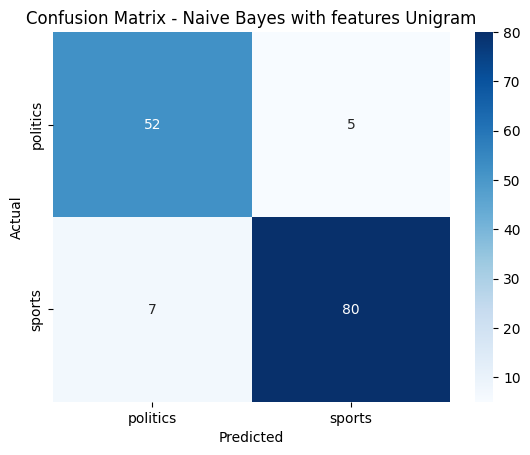

Validation Accuracy for model Logistic Regression with features Unigram: 0.9510
--------------------------------------------------
Test of model Logistic Regression with features Unigram
--------------------------------------------------
Accuracy: 0.902778
Precision: 0.902778
Recall: 0.902778
f1 Score: 0.902778
--------------------------------------------------




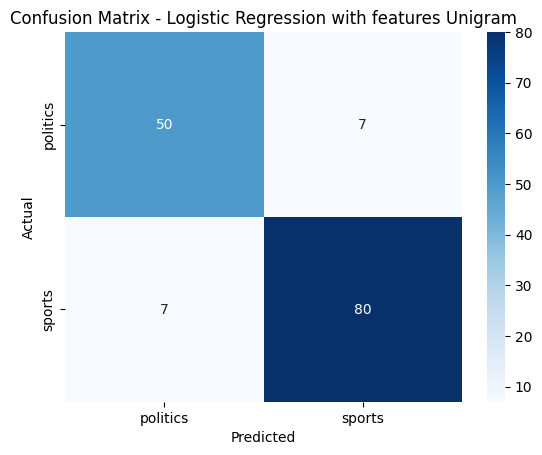

/home/sumeet/Sumeet/IITJ/Sem VIII/8.3 Natural Language Understanding/8.3.1_A1/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Validation Accuracy for model Linear SVM with features Unigram: 0.9091
--------------------------------------------------
Test of model Linear SVM with features Unigram
--------------------------------------------------
Accuracy: 0.868056
Precision: 0.867729
Recall: 0.868056
f1 Score: 0.867849
--------------------------------------------------




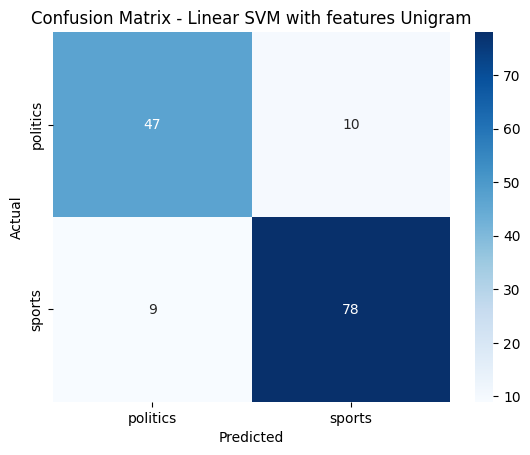

--------------------------------------------------
For Feature Unigram
--------------------------------------------------
                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.916667   0.917498  0.916667  0.916901
1  Logistic Regression  0.902778   0.902778  0.902778  0.902778
2           Linear SVM  0.868056   0.867729  0.868056  0.867849
Validation Accuracy for model Naive Bayes with features Bag of Words: 0.8951
--------------------------------------------------
Test of model Naive Bayes with features Bag of Words
--------------------------------------------------
Accuracy: 0.902778
Precision: 0.903681
Recall: 0.902778
f1 Score: 0.903051
--------------------------------------------------




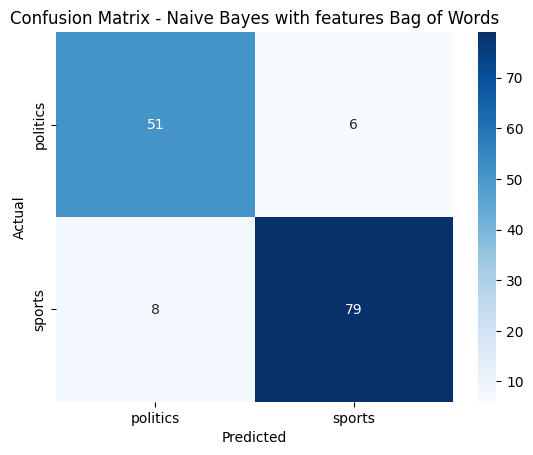

Validation Accuracy for model Logistic Regression with features Bag of Words: 0.9371
--------------------------------------------------
Test of model Logistic Regression with features Bag of Words
--------------------------------------------------
Accuracy: 0.909722
Precision: 0.910076
Recall: 0.909722
f1 Score: 0.909854
--------------------------------------------------




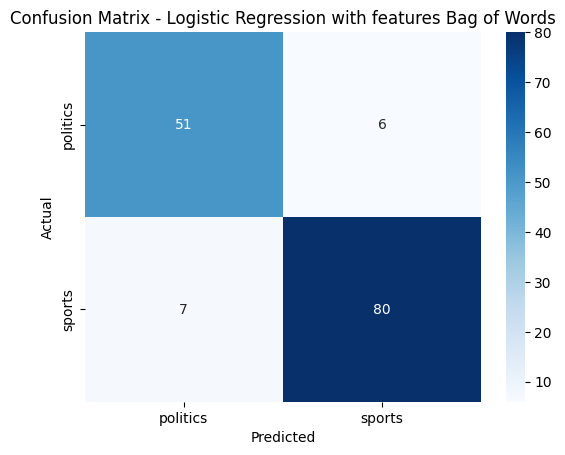

Validation Accuracy for model Linear SVM with features Bag of Words: 0.9021
--------------------------------------------------
Test of model Linear SVM with features Bag of Words
--------------------------------------------------
Accuracy: 0.875000
Precision: 0.875000
Recall: 0.875000
f1 Score: 0.875000
--------------------------------------------------




/home/sumeet/Sumeet/IITJ/Sem VIII/8.3 Natural Language Understanding/8.3.1_A1/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


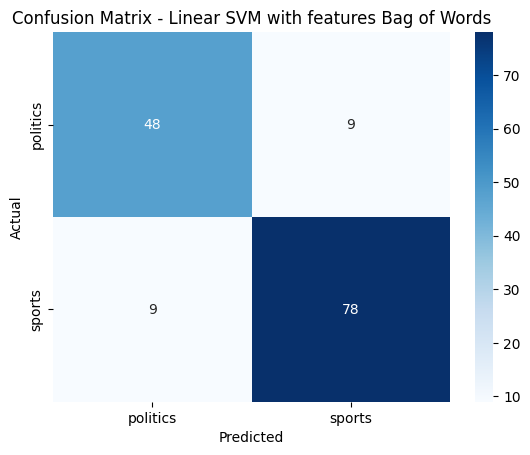

--------------------------------------------------
For Feature Bag of Words
--------------------------------------------------
                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.902778   0.903681  0.902778  0.903051
1  Logistic Regression  0.909722   0.910076  0.909722  0.909854
2           Linear SVM  0.875000   0.875000  0.875000  0.875000
Validation Accuracy for model Naive Bayes with features TF-IDF: 0.9301
--------------------------------------------------
Test of model Naive Bayes with features TF-IDF
--------------------------------------------------
Accuracy: 0.909722
Precision: 0.914280
Recall: 0.909722
f1 Score: 0.908073
--------------------------------------------------




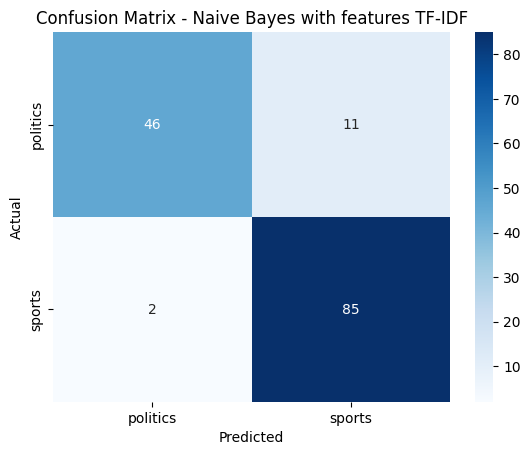

Validation Accuracy for model Logistic Regression with features TF-IDF: 0.9161
--------------------------------------------------
Test of model Logistic Regression with features TF-IDF
--------------------------------------------------
Accuracy: 0.909722
Precision: 0.921458
Recall: 0.909722
f1 Score: 0.907050
--------------------------------------------------




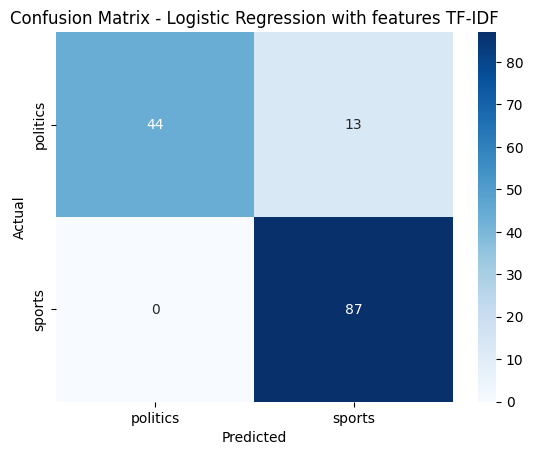

Validation Accuracy for model Linear SVM with features TF-IDF: 0.9301
--------------------------------------------------
Test of model Linear SVM with features TF-IDF
--------------------------------------------------
Accuracy: 0.923611
Precision: 0.923688
Recall: 0.923611
f1 Score: 0.923226
--------------------------------------------------




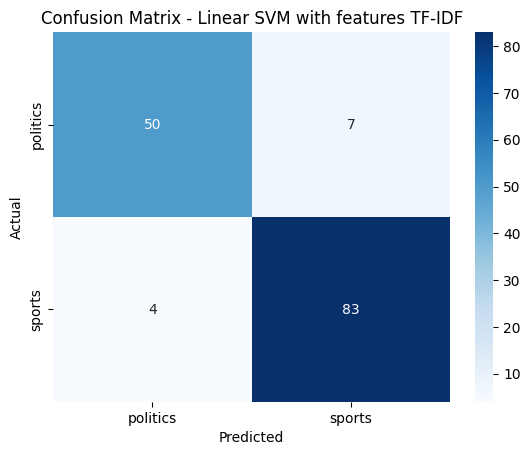

--------------------------------------------------
For Feature TF-IDF
--------------------------------------------------
                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.909722   0.914280  0.909722  0.908073
1  Logistic Regression  0.909722   0.921458  0.909722  0.907050
2           Linear SVM  0.923611   0.923688  0.923611  0.923226


In [58]:
for feature_label,feature_type in features.items():
    feature_wise_model_comparison = []

    for model_label,model_type in models.items():
        model, (test_acc, test_prec, test_recall, test_f1), _ = train_and_test_pipeline(data,feature_type,model_type,model_label,feature_label)

        feature_wise_model_comparison.append([model_label,test_acc,test_prec,test_recall,test_f1])

    results_df = pd.DataFrame(
        feature_wise_model_comparison,
        columns=['Model','Accuracy','Precision','Recall','F1-score']
    )

    print(f"{'-'*50}\nFor Feature {feature_label}\n{'-'*50}")
    print(results_df)

In [65]:
df.iloc[0].text

'Mikel Arteta was crestfallen after Arsenal’s defeat to West Ham (Photo: Amazon Prime) Mikel Arteta says the technology VAR are using is ‘not good enough’ after West Ham scored a controversial goal in their win over Arsenal. The Gunners missed an opportunity to got top of the Premier League after shockingly losing 2-0 to the Irons at the Emirates on Thursday night. Tomas Soucek scored the opener before a goal from former Arsenal defender Konstantinos Mavropanos sealed the victory as Mikel Arteta’s side missed numerous chances. There was controversy surrounding Soucek’s strike however, as the ball appeared to go out of play in the build-up but VAR could not rule it out as it could not conclusively prove it had fully crossed the line. The incident echoed Newcastle’s winning goal against Arsenal earlier this season, which had prompted Arteta’s infamous rant on the referees. The manager was far more reserved and measured this time around however, and when asked about the Soucek goal he rep